GOALS:
1) Prove I can select files using file names and date range. 
1) Process 1 UIUC file
2) Process 1 USC file

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent / "src"))

from config import load_config
from lidar.files import find_files_by_time, get_selected_file_paths

In [3]:
# test loading config 
paths = load_config('paths.yml')
usc_dir =  paths['paths']['usc_interim_dir']
uiuc_dir =  paths['paths']['uiuc_interim_dir']
lidar_dir = paths['paths']['lidar_dir']

print(lidar_dir)
print(uiuc_dir)
print(usc_dir)

C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim
C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/UIUC
C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/USC


In [4]:
# find all uiuc lidar data from a specific time range
uiuc_table = find_files_by_time(
    root_dir=uiuc_dir,
    source="UIUC",
    start_time="2018-10-15 23:00:00",
    end_time="2018-10-16 00:00:00",
)

uiuc_table

,file_path,file_name,file_time,parse_error,selected
0,C:\Users\ben\OneDrive - University of South Ca...,R1892323.023046.csv,2018-09-23 23:02:30.460,None,False
1,C:\Users\ben\OneDrive - University of South Ca...,R1892323.023545.csv,2018-09-23 23:02:35.450,None,False
2,C:\Users\ben\OneDrive - University of South Ca...,R1892323.024013.csv,2018-09-23 23:02:40.130,None,False
3,C:\Users\ben\OneDrive - University of South Ca...,R1892323.024571.csv,2018-09-23 23:02:45.710,None,False
4,C:\Users\ben\OneDrive - University of South Ca...,R1892323.024929.csv,2018-09-23 23:02:49.290,None,False
...,...,...,...,...,...
46044,C:\Users\ben\OneDrive - University of South Ca...,R18B1407.404416.csv,2018-11-14 07:40:44.160,None,False
46045,C:\Users\ben\OneDrive - University of South Ca...,R18B1407.404964.csv,2018-11-14 07:40:49.640,None,False
46046,C:\Users\ben\OneDrive - University of South Ca...,R18B1407.405246.csv,2018-11-14 07:40:52.460,None,False
46047,C:\Users\ben\OneDrive - University of South Ca...,R18B1407.405794.csv,2018-11-14 07:40:57.940,None,False


In [5]:
uiuc_files = get_selected_file_paths(uiuc_table)
len(uiuc_files)

14

In [6]:
usc_table = find_files_by_time(
    root_dir=usc_dir,
    source="USC",
    start_time="2018-11-02 23:00:00",
    end_time="2018-11-03 00:00:00",
)

len(usc_table)

18934

In [7]:
usc_files = get_selected_file_paths(usc_table)
len(usc_files)

728

In [8]:
usc_files

[WindowsPath('C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/USC/11022018/S18B0223.000248.txt'),
 WindowsPath('C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/USC/11022018/S18B0223.000638.txt'),
 WindowsPath('C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/USC/11022018/S18B0223.001033.txt'),
 WindowsPath('C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/USC/11022018/S18B0223.001452.txt'),
 WindowsPath('C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/USC/11022018/S18B0223.001863.txt'),
 WindowsPath('C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/USC/11022018/S18B0223.002223.txt'),
 WindowsPath('C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/USC/11022018/S18B0223.002643.txt'),
 WindowsPath('C:/Users/ben/OneDrive - University of South Carolina/SAVANT_Data/01_interim/USC/11022018/S18B0223.003063

# Now working on parsing the header and profile data.

In [25]:
uiuc_sample = uiuc_files[10]
print(uiuc_sample)
usc_sample = usc_files[0]
print(usc_sample)

C:\Users\ben\OneDrive - University of South Carolina\SAVANT_Data\01_interim\UIUC\10152018\R18A1523.494852.csv
C:\Users\ben\OneDrive - University of South Carolina\SAVANT_Data\01_interim\USC\11022018\S18B0223.000248.txt


In [26]:
from lidar.simple_parser import read_lidar_file

In [27]:
# meta, profile = read_lidar_file(usc_sample, 'USC', 6)
meta, profile = read_lidar_file(uiuc_sample, 'UIUC', 14)

In [28]:
profile

,range_bin,range_m,0 (mV),1 (counts),2 (mV),3 (counts),4 (mV),5 (counts),6 (mV),7 (counts),8 (counts),9 (counts)
0,0,1.875,9.0529,67.0,0.0,0.0,9.3494,77.0,0.0,0.0,57.0,0.0
1,1,5.625,9.0965,58.0,0.0,0.0,9.3738,82.0,0.0,0.0,55.0,0.0
2,2,9.375,9.1837,37.0,0.0,0.0,9.3860,86.0,0.0,0.0,53.0,0.0
3,3,13.125,9.0877,47.0,0.0,0.0,9.3721,66.0,0.0,0.0,38.0,0.0
4,4,16.875,9.1139,35.0,0.0,0.0,9.3651,76.0,0.0,0.0,51.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16375,16375,61408.125,9.0965,0.0,0.0,0.0,9.3790,0.0,0.0,0.0,0.0,0.0
16376,16376,61411.875,9.1226,0.0,0.0,0.0,9.3651,0.0,0.0,0.0,0.0,0.0
16377,16377,61415.625,9.1226,0.0,0.0,0.0,9.3581,0.0,0.0,0.0,0.0,0.0
16378,16378,61419.375,9.1052,0.0,0.0,0.0,9.3686,0.0,0.0,0.0,0.0,0.0


In [29]:
profile.columns

Index(['range_bin', 'range_m', '0 (mV)', ' 1 (counts)', ' 2 (mV)',
       ' 3 (counts)', ' 4 (mV)', ' 5 (counts)', ' 6 (mV)', ' 7 (counts)',
       ' 8 (counts)', ' 9 (counts)'],
      dtype='str')

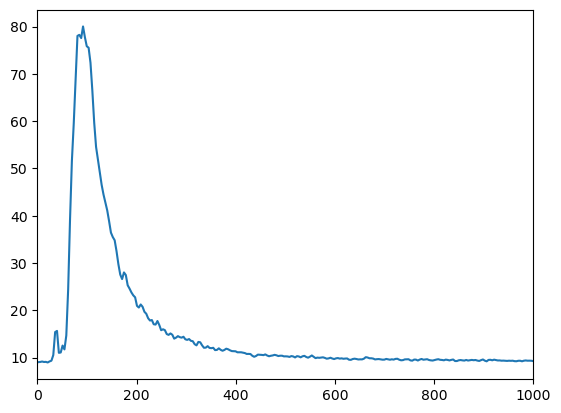

In [30]:
plt.plot(profile['range_m'], profile['0 (mV)'])
plt.xlim(0,1000)
plt.show()

In [34]:
meta['dataset_descriptors']

[{'dataset_index': 0,
  'raw_descriptor': '1 0 1 16380 1 0780 3.75 00355.p 0 0 09 000 12 000014 0.500 BT0',
  'dataset_present': 1,
  'signal_mode': 0,
  'laser_source': 1,
  'n_bins': 16380,
  'pmt_high_voltage': 780.0,
  'bin_width_m': 3.75,
  'wavelength_nm': '00355.p',
  'dataset_label': '0.500',
  'recorder': 'BT0'},
 {'dataset_index': 1,
  'raw_descriptor': '1 1 1 16380 1 0780 3.75 00355.p 0 0 00 000 00 000014 4.3651 BC0',
  'dataset_present': 1,
  'signal_mode': 1,
  'laser_source': 1,
  'n_bins': 16380,
  'pmt_high_voltage': 780.0,
  'bin_width_m': 3.75,
  'wavelength_nm': '00355.p',
  'dataset_label': '4.3651',
  'recorder': 'BC0'},
 {'dataset_index': 2,
  'raw_descriptor': '1 0 1 16380 1 0780 3.75 00355.p 0 0 09 000 12 000013 0.500 BT0',
  'dataset_present': 1,
  'signal_mode': 0,
  'laser_source': 1,
  'n_bins': 16380,
  'pmt_high_voltage': 780.0,
  'bin_width_m': 3.75,
  'wavelength_nm': '00355.p',
  'dataset_label': '0.500',
  'recorder': 'BT0'},
 {'dataset_index': 3,
  'r

In [37]:
for row in meta['dataset_descriptors']:
    print(row['raw_descriptor'])

1 0 1 16380 1 0780 3.75 00355.p 0 0 09 000 12 000014 0.500 BT0
1 1 1 16380 1 0780 3.75 00355.p 0 0 00 000 00 000014 4.3651 BC0
1 0 1 16380 1 0780 3.75 00355.p 0 0 09 000 12 000013 0.500 BT0
1 1 1 16380 1 0780 3.75 00355.p 0 0 00 000 00 000013 4.3651 BC0
1 0 1 16380 1 0780 3.75 00355.s 0 0 09 000 12 000014 0.100 BT1
1 1 1 16380 1 0780 3.75 00355.s 0 0 00 000 00 000014 4.3651 BC1
1 0 1 16380 1 0780 3.75 00355.s 0 0 09 000 12 000013 0.100 BT1
1 1 1 16380 1 0780 3.75 00355.s 0 0 00 000 00 000013 4.3651 BC1
1 1 2 16380 1 0850 3.75 00387.o 0 0 00 000 00 000014 4.3651 BC2
1 1 2 16380 1 0850 3.75 00387.o 0 0 00 000 00 000013 4.3651 BC2
